## Student Performance Indicator


#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [15]:
df = pd.read_csv('data/stud.csv')

#### Show Top 5 Records

In [16]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [17]:
df.shape

(1000, 8)

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [18]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### There are no missing values in the data set

In [19]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates  values in the data set

In [20]:
# Check Null and Dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 3.4 Checking the number of unique values of each column

In [21]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check statistics of data set

In [22]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.6 Exploring Data

In [23]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [24]:
categorical_cols = [
    'gender',
    'race_ethnicity',
    'parental_level_of_education',
    'lunch',
    'test_preparation_course'
]

for col in categorical_cols:
    print(f"Categories in '{col}':", df[col].unique().tolist())

Categories in 'gender': ['female', 'male']
Categories in 'race_ethnicity': ['group B', 'group C', 'group A', 'group D', 'group E']
Categories in 'parental_level_of_education': ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
Categories in 'lunch': ['standard', 'free/reduced']
Categories in 'test_preparation_course': ['none', 'completed']


In [25]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [26]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


### 3.7 Adding columns for "Total Score" and "Average"

In [27]:
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [28]:
print(df['gender'].dtype)

str


In [29]:
# Count students who scored full marks (100)

reading_full = (df['reading_score'] == 100).sum()
writing_full = (df['writing_score'] == 100).sum()
math_full = (df['math_score'] == 100).sum()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [30]:
reading_less_20 = (df['reading_score'] <= 20).sum()
writing_less_20 = (df['writing_score'] <= 20).sum()
math_less_20 = (df['math_score'] <= 20).sum()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

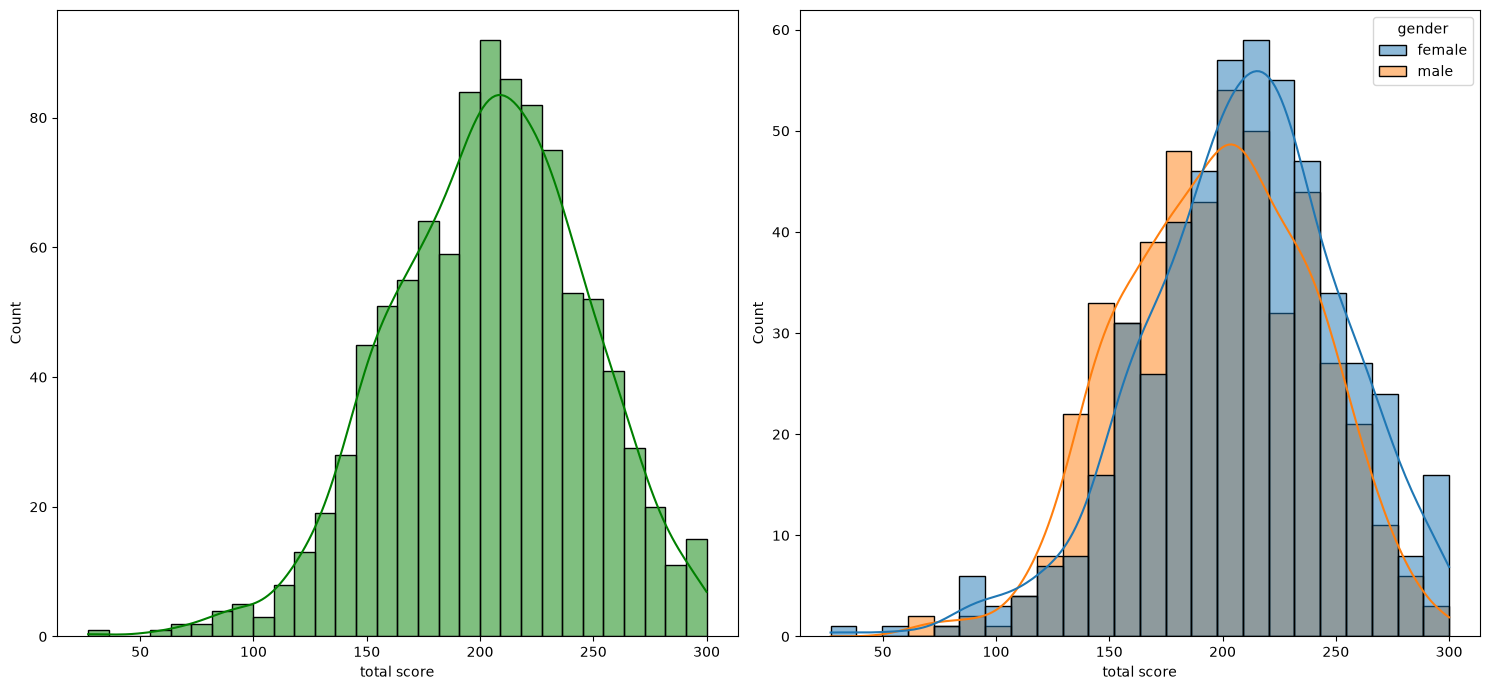

In [32]:
plt.figure(figsize=(15, 7))

plt.subplot(121) # 1 row, 2 columns, plot 1
sns.histplot(data=df, x='total score', bins=30, kde=True, color='green')

plt.subplot(122) # 1 row, 2 columns, plot 2
sns.histplot(data=df, x='total score', kde=True, hue='gender')

plt.tight_layout()
plt.show()

#####  Insights
- Female students tend to perform well then male students.

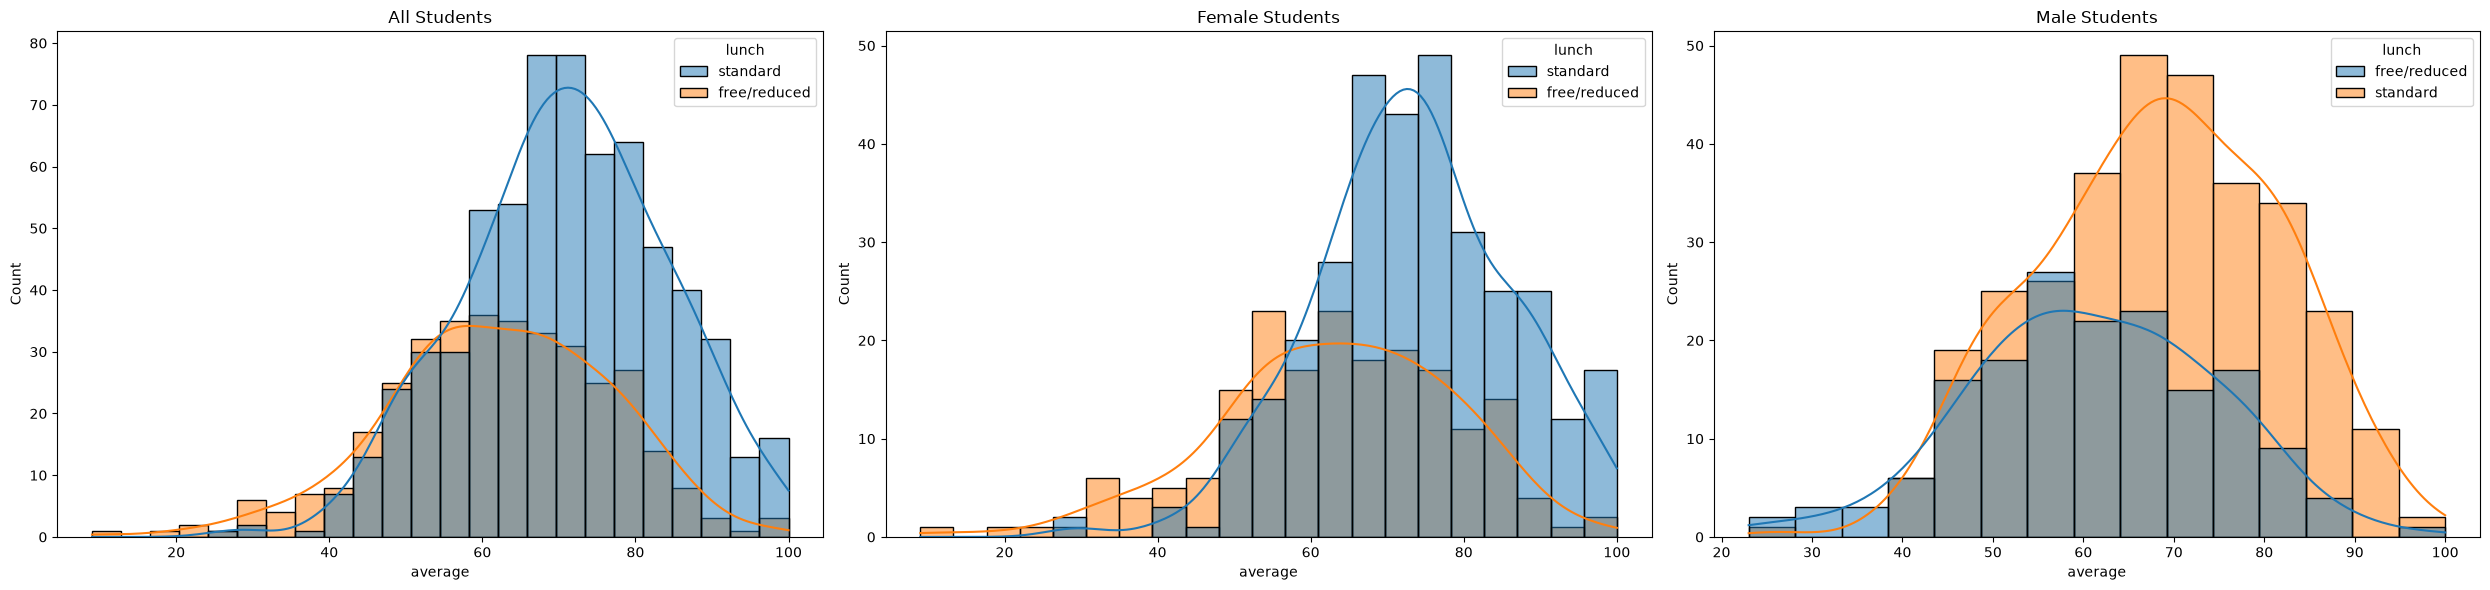

In [33]:
plt.figure(figsize=(25, 6))

# Overall distribution by lunch type
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='average', kde=True, hue='lunch')
plt.title("All Students")

# Female students
plt.subplot(1, 3, 2)
sns.histplot(data=df[df['gender'] == 'female'], x='average', kde=True, hue='lunch')
plt.title("Female Students")

# Male students
plt.subplot(1, 3, 3)
sns.histplot(data=df[df['gender'] == 'male'], x='average', kde=True, hue='lunch')
plt.title("Male Students")

plt.tight_layout()
plt.show()

#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

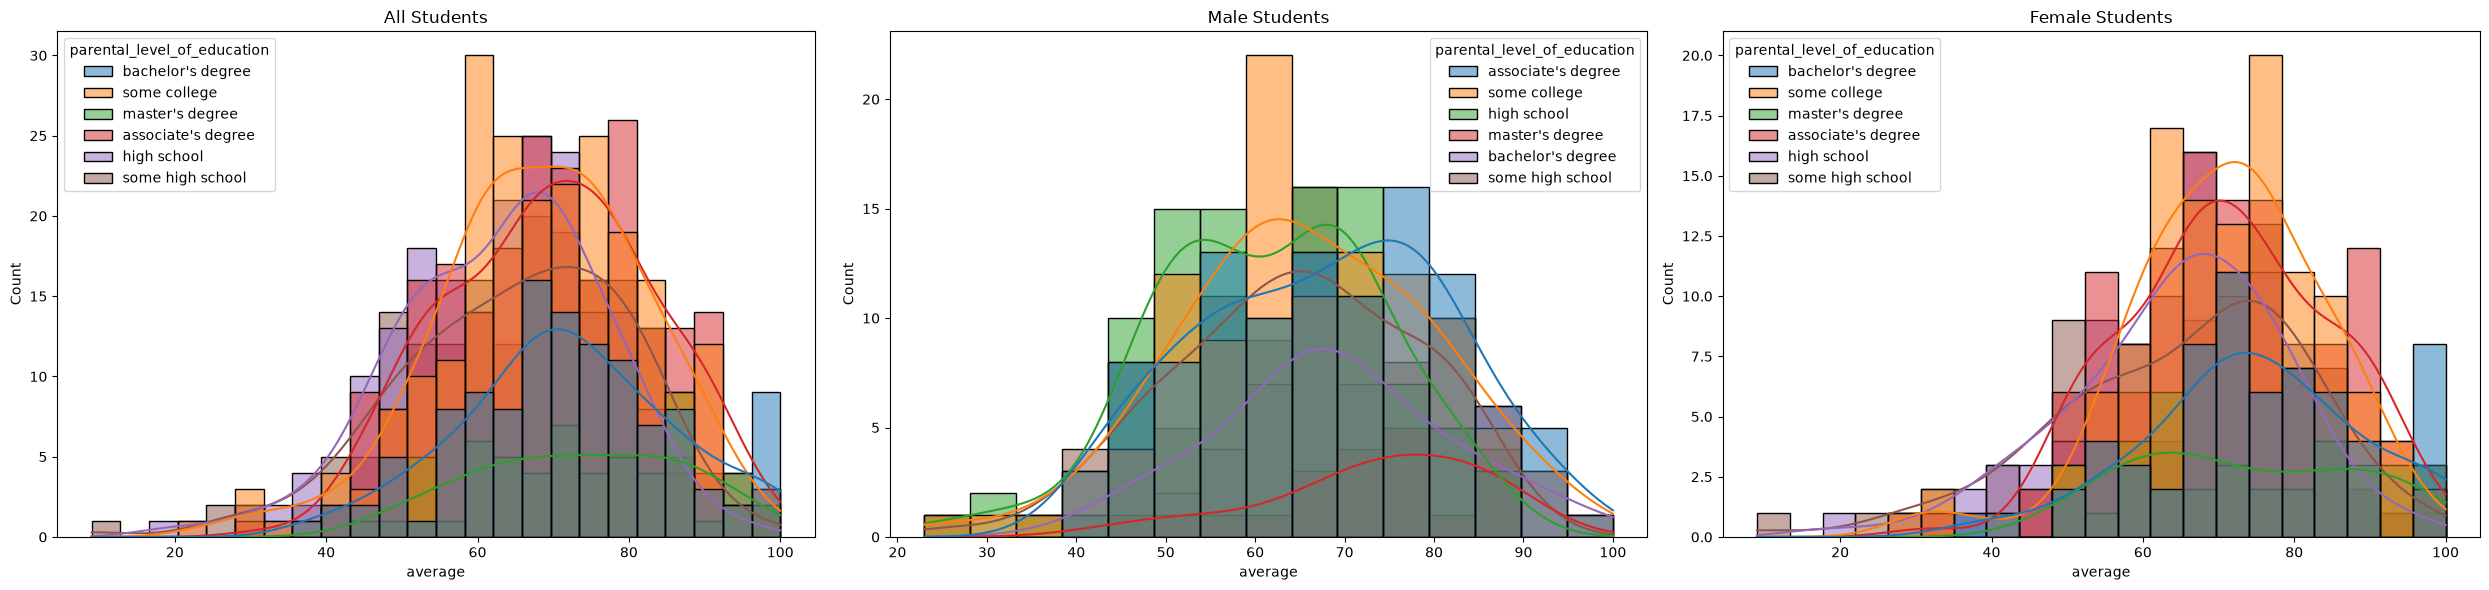

In [34]:
plt.figure(figsize=(25, 6))

# All students
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='average', kde=True, hue='parental_level_of_education')
plt.title("All Students")

# Male students
plt.subplot(1, 3, 2)
sns.histplot(data=df[df['gender'] == 'male'], x='average', kde=True, hue='parental_level_of_education')
plt.title("Male Students")

# Female students
plt.subplot(1, 3, 3)
sns.histplot(data=df[df['gender'] == 'female'], x='average', kde=True, hue='parental_level_of_education')
plt.title("Female Students")

plt.tight_layout()
plt.show()

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

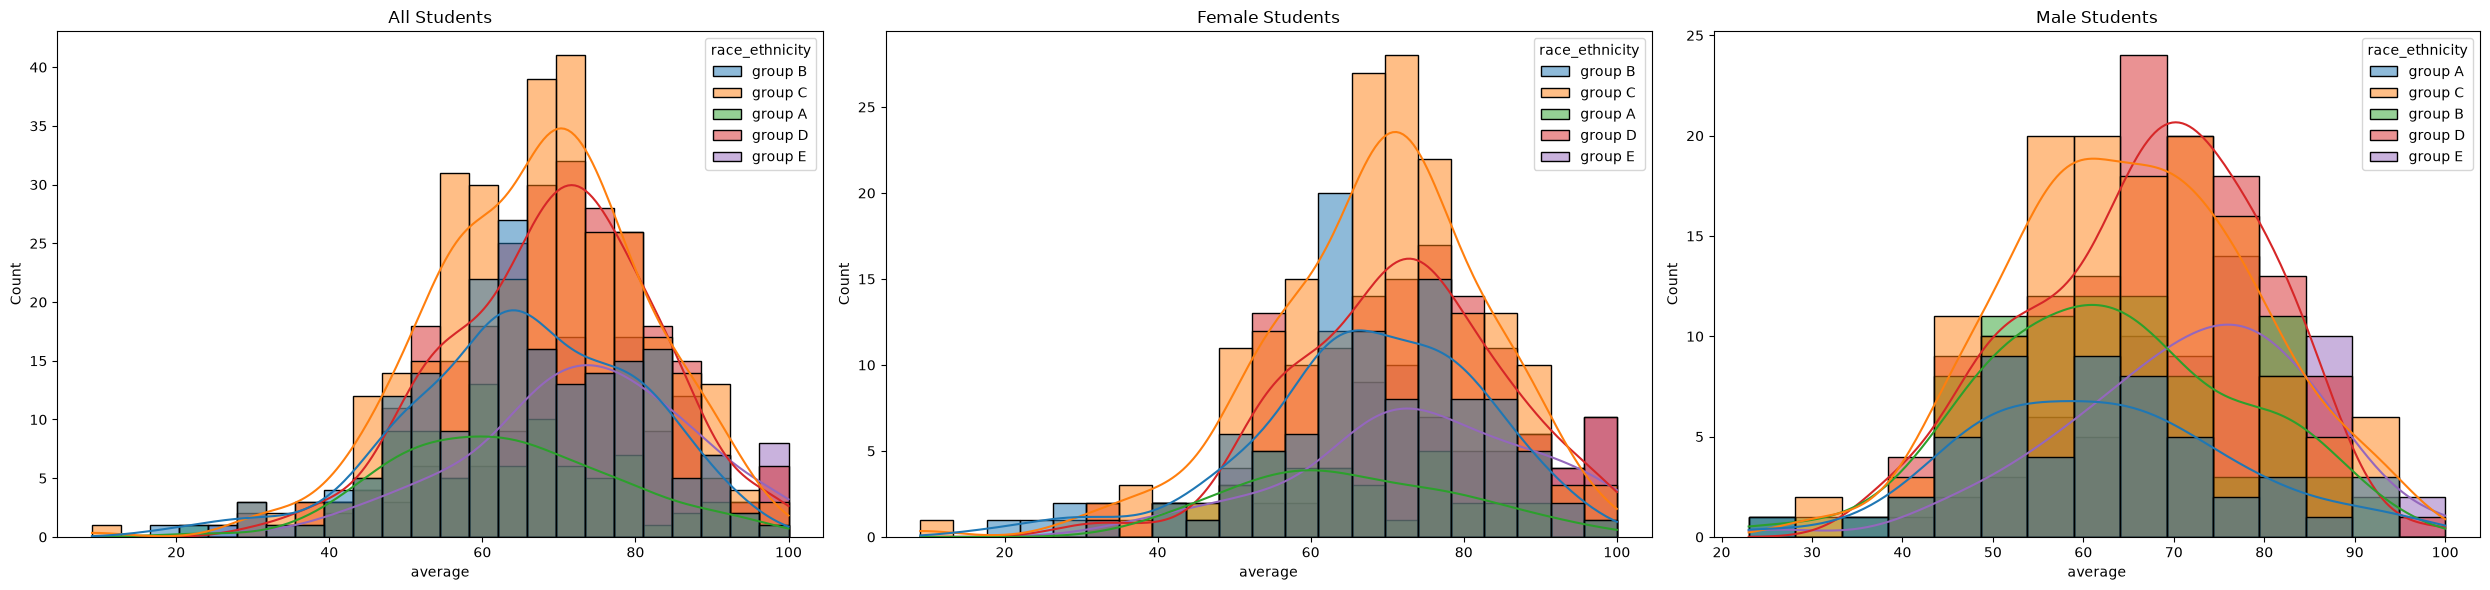

In [35]:
plt.figure(figsize=(25, 6))

# All students
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='average', kde=True, hue='race_ethnicity')
plt.title("All Students")

# Female students
plt.subplot(1, 3, 2)
sns.histplot(data=df[df['gender'] == 'female'], x='average', kde=True, hue='race_ethnicity')
plt.title("Female Students")

# Male students
plt.subplot(1, 3, 3)
sns.histplot(data=df[df['gender'] == 'male'], x='average', kde=True, hue='race_ethnicity')
plt.title("Male Students")

plt.tight_layout()
plt.show()

#####  Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

#### 4.2 Maximumum score of students in all three subjects

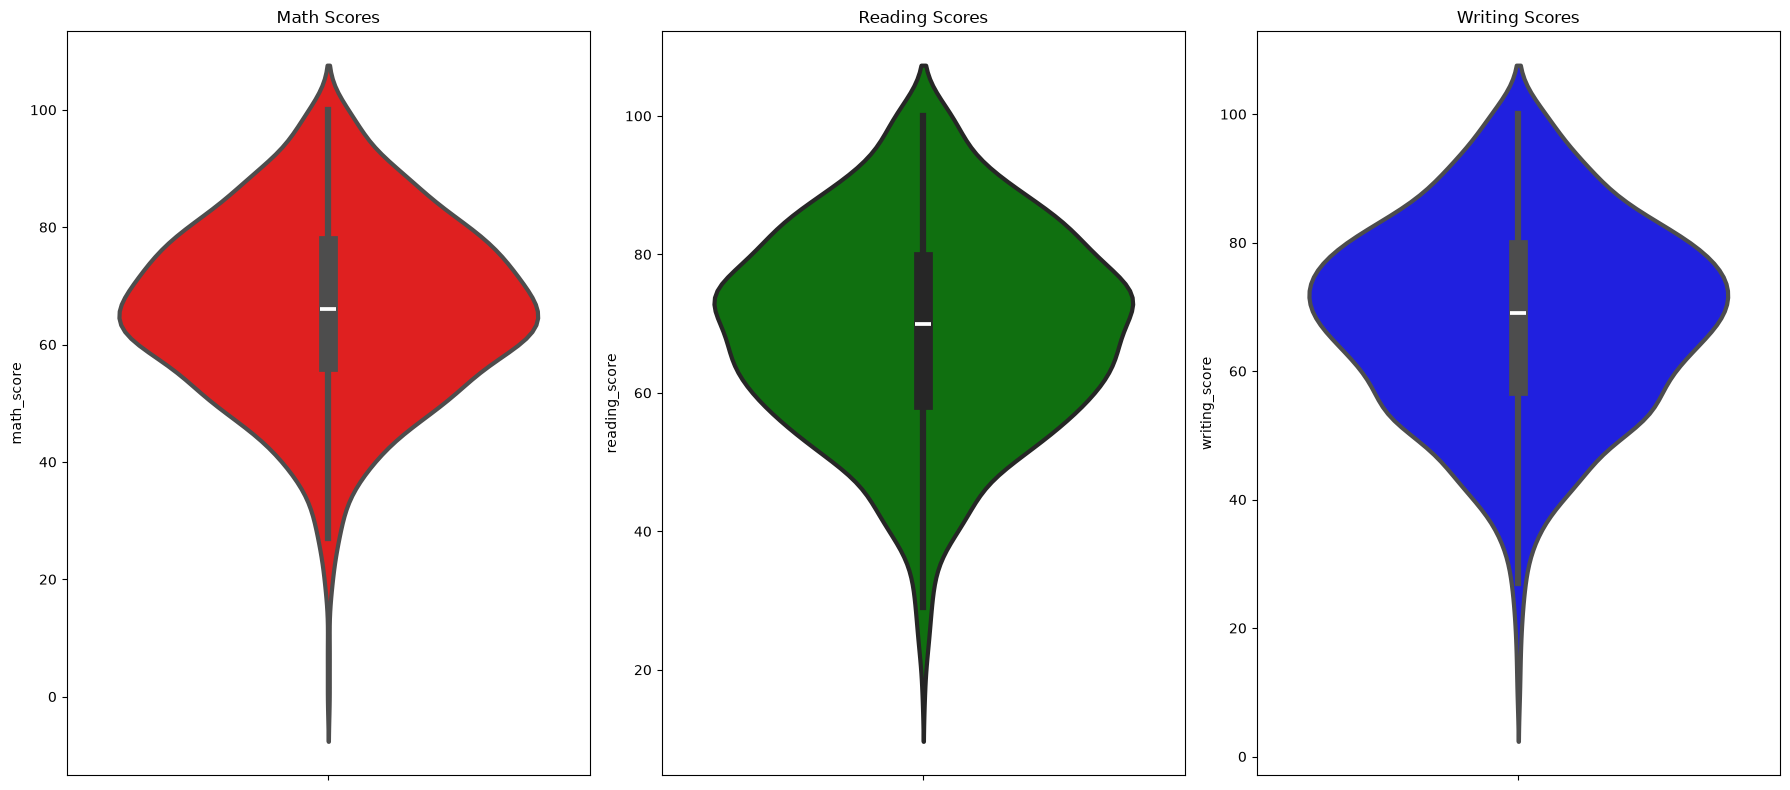

In [36]:
plt.figure(figsize=(18, 8))

# Math Scores
plt.subplot(1, 3, 1)
sns.violinplot(data=df, y='math_score', color='red', linewidth=3)
plt.title("Math Scores")

# Reading Scores
plt.subplot(1, 3, 2)
sns.violinplot(data=df, y='reading_score', color='green', linewidth=3)
plt.title("Reading Scores")

# Writing Scores
plt.subplot(1, 3, 3)
sns.violinplot(data=df, y='writing_score', color='blue', linewidth=3)
plt.title("Writing Scores")

plt.tight_layout()
plt.show()

In [40]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


#### 4.3 Univariate Analysis of Categorical Features

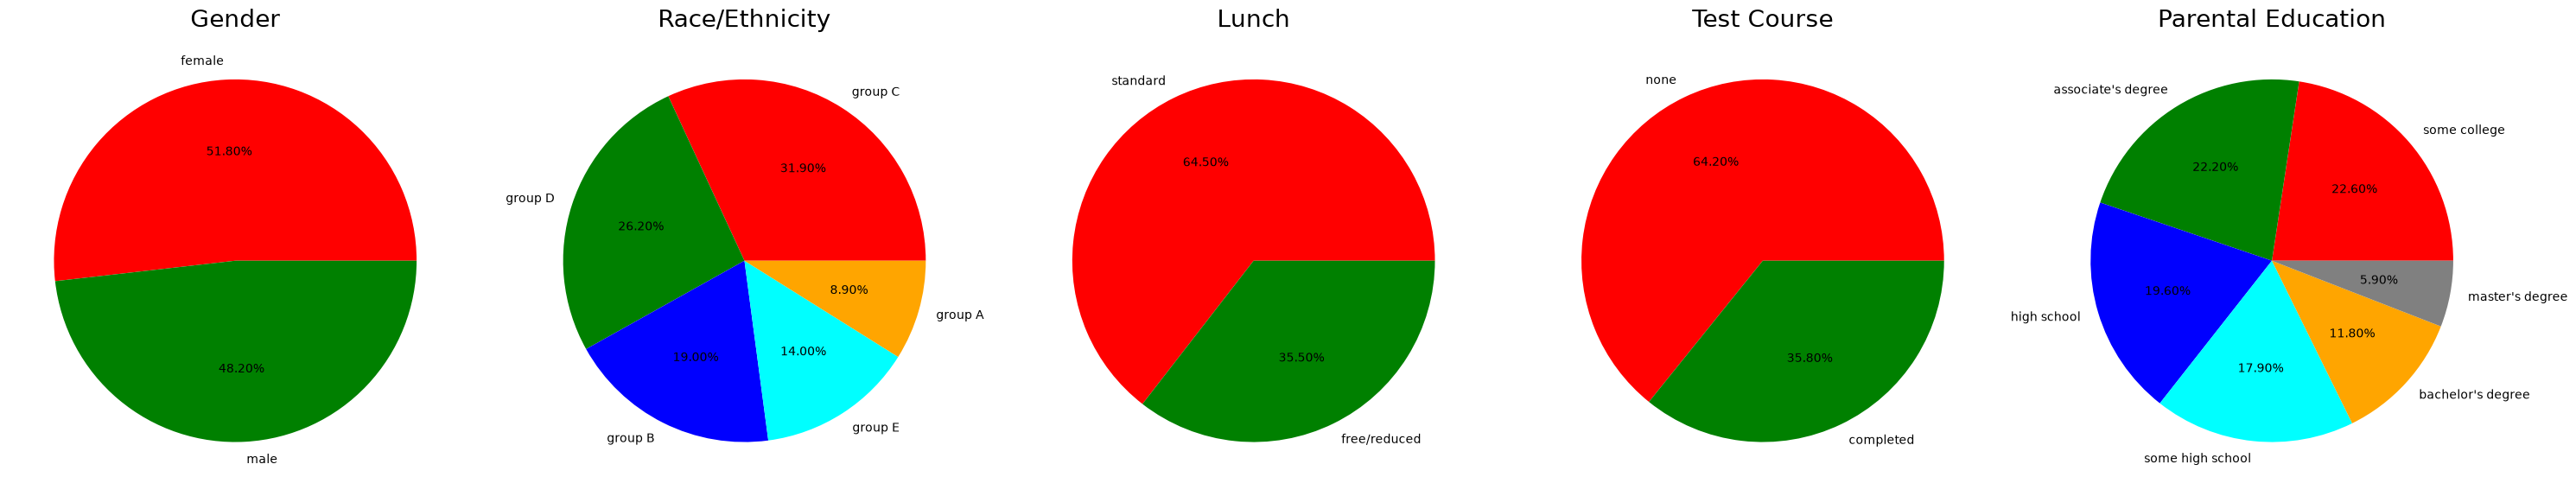

In [ ]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = size.index.tolist()
color = ['red', 'green']
plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = size.index.tolist()
color = ['red', 'green', 'blue', 'cyan', 'orange']
plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Race/Ethnicity', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = size.index.tolist()
color = ['red', 'green']
plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = size.index.tolist()
color = ['red', 'green']
plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Test Course', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = size.index.tolist()
color = ['red', 'green', 'blue', 'cyan', 'orange', 'grey']
plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Parental Education', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.show()           

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

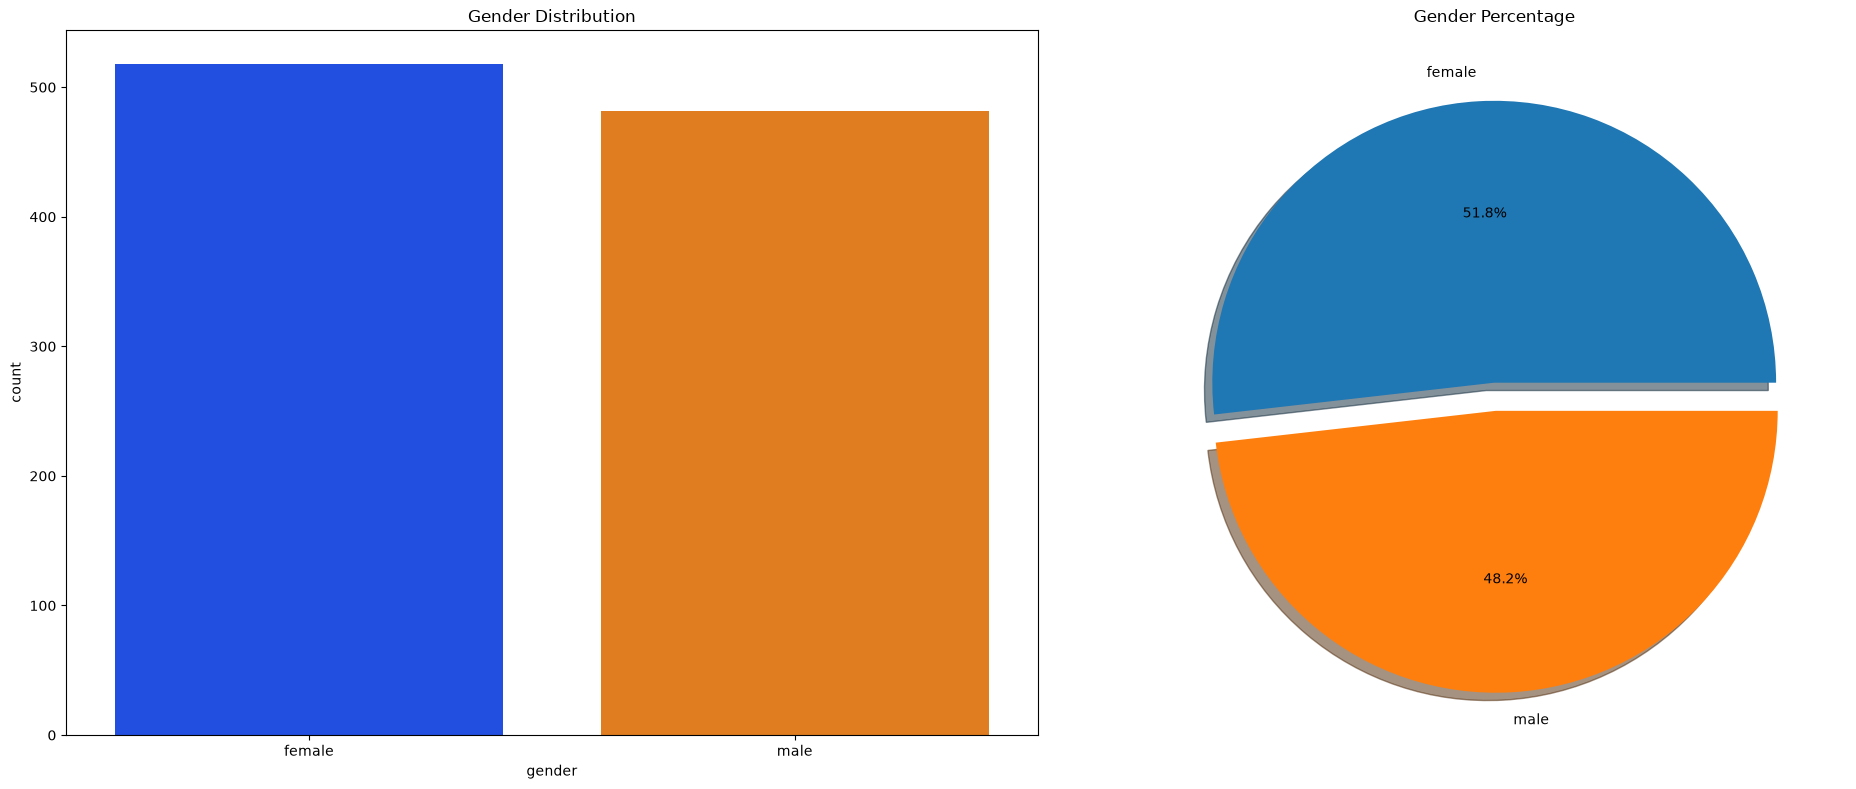

In [51]:
plt.figure(figsize=(20, 8))

# Count Plot
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='gender', palette='bright')
plt.title("Gender Distribution")

# Pie Chart
plt.subplot(1, 2, 2)
plt.pie(
    df['gender'].value_counts(),
    labels=df['gender'].value_counts().index, # .index extracts just the names from value_counts result
    autopct='%1.1f%%',
    explode=(0, 0.1),
    shadow=True
)
plt.title("Gender Percentage")

plt.tight_layout()
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

In [62]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

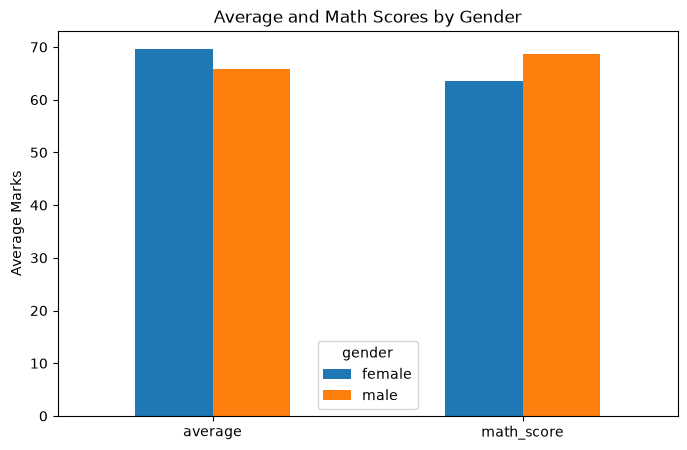

In [74]:
gender_group = (
    df.groupby('gender')[['average', 'math_score']].mean().T
)

gender_group.plot(kind='bar',figsize=(8, 5))
plt.ylabel("Average Marks")
plt.title("Average and Math Scores by Gender")
plt.xticks(rotation=0)
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

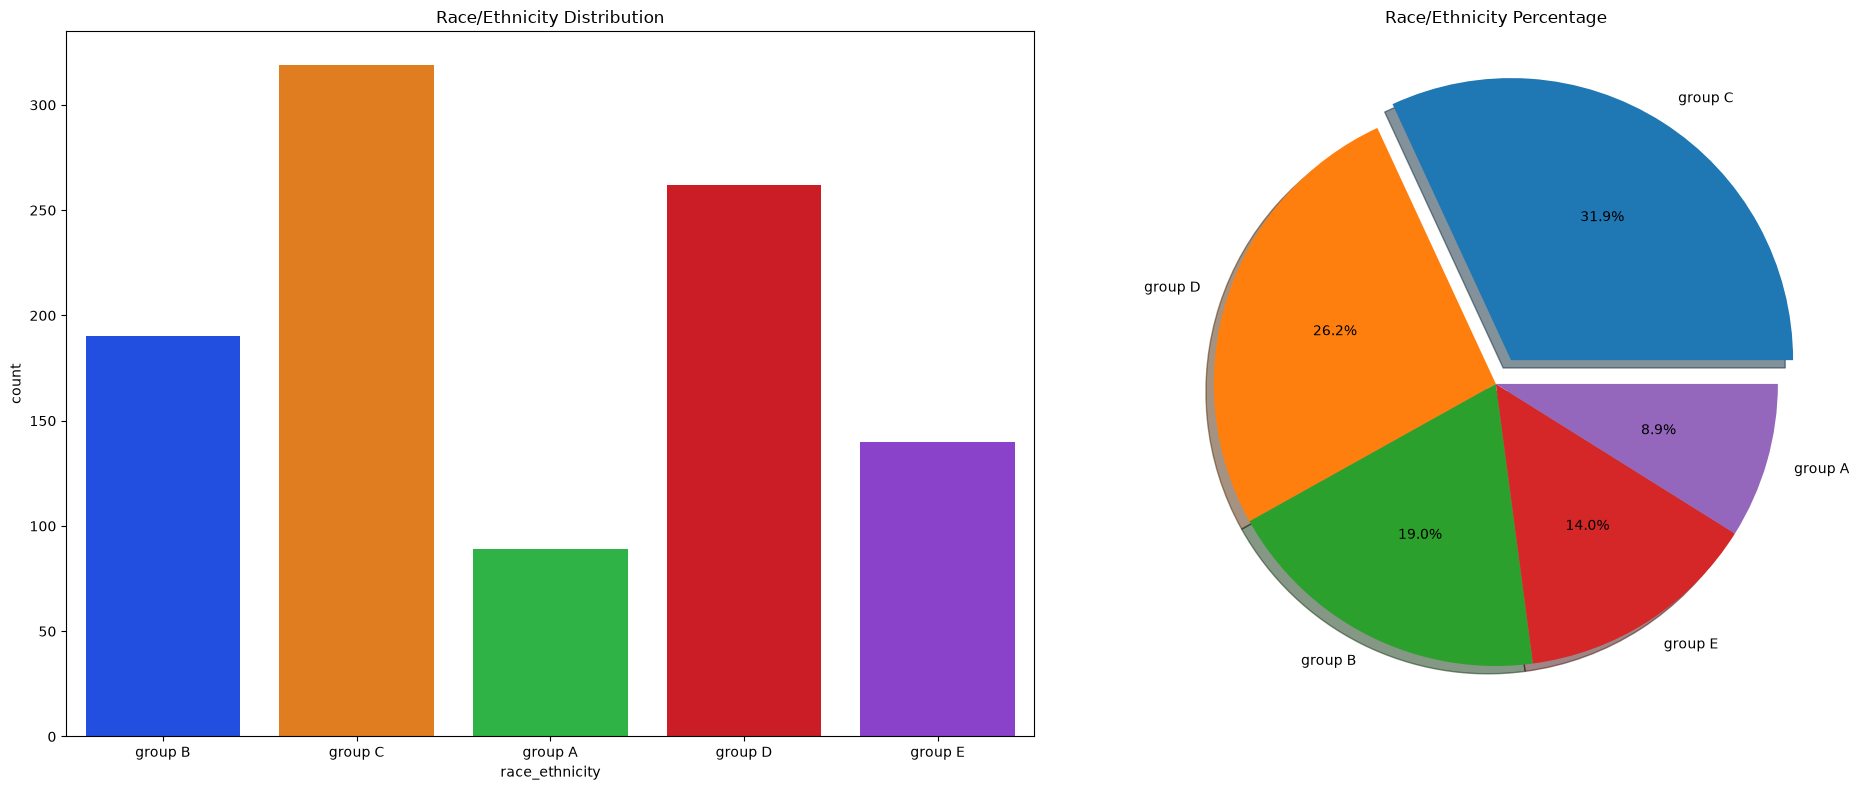

In [75]:
plt.figure(figsize=(20, 8))

# Count Plot
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='race_ethnicity', palette='bright')
plt.title("Race/Ethnicity Distribution")

# Pie Chart
plt.subplot(1, 2, 2)
plt.pie(
    df['race_ethnicity'].value_counts(),
    labels=df['race_ethnicity'].value_counts().index,# .index extracts just the names from value_counts result
    autopct='%1.1f%%',
    explode=(0.1, 0, 0, 0, 0),
    shadow=True
)
plt.title("Race/Ethnicity Percentage")

plt.tight_layout()
plt.show()

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to group A.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

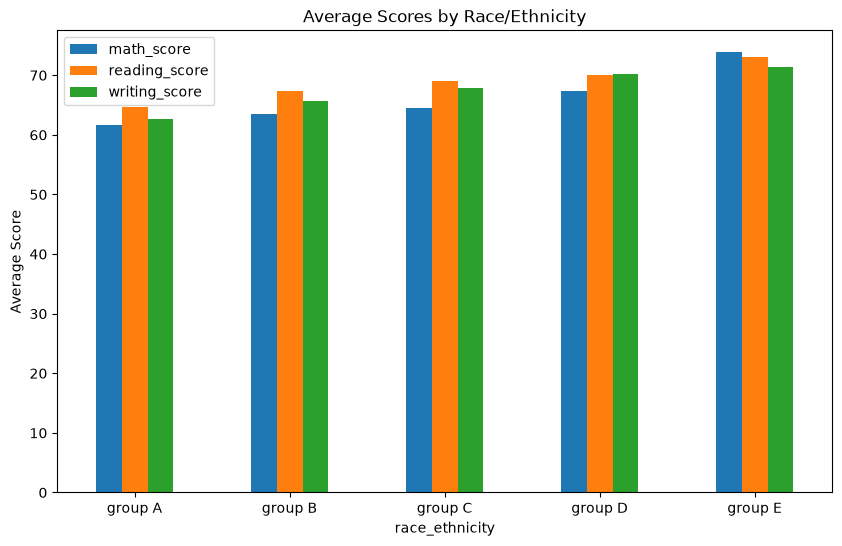

In [79]:
race_group = (
    df.groupby('race_ethnicity')[['math_score', 'reading_score', 'writing_score']]
      .mean()
)

race_group.plot(kind='bar', figsize=(10, 6))

plt.ylabel("Average Score")
plt.title("Average Scores by Race/Ethnicity")
plt.xticks(rotation=0)
plt.show()

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

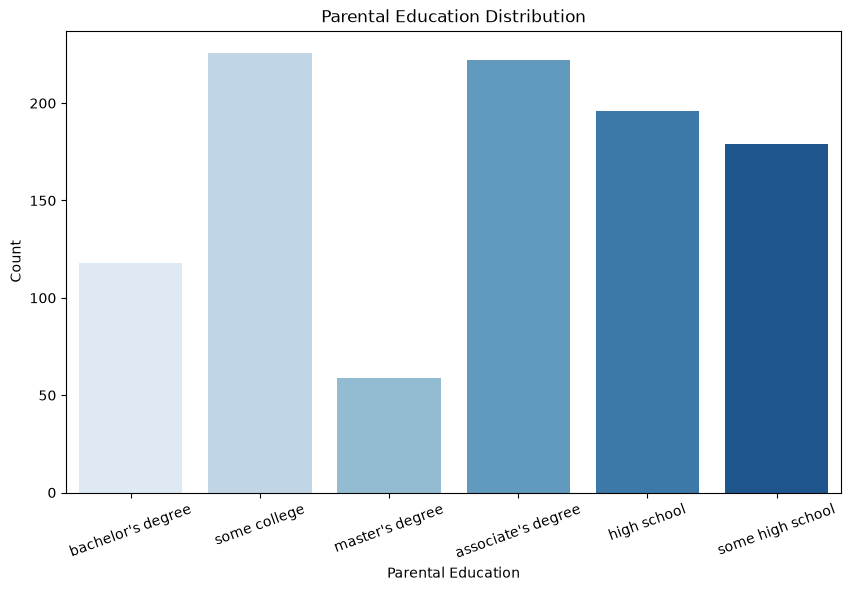

In [80]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='parental_level_of_education', palette='Blues')

plt.title("Parental Education Distribution")
plt.xlabel("Parental Education")
plt.ylabel("Count")
plt.xticks(rotation=20)

plt.show()

#### Insights 
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

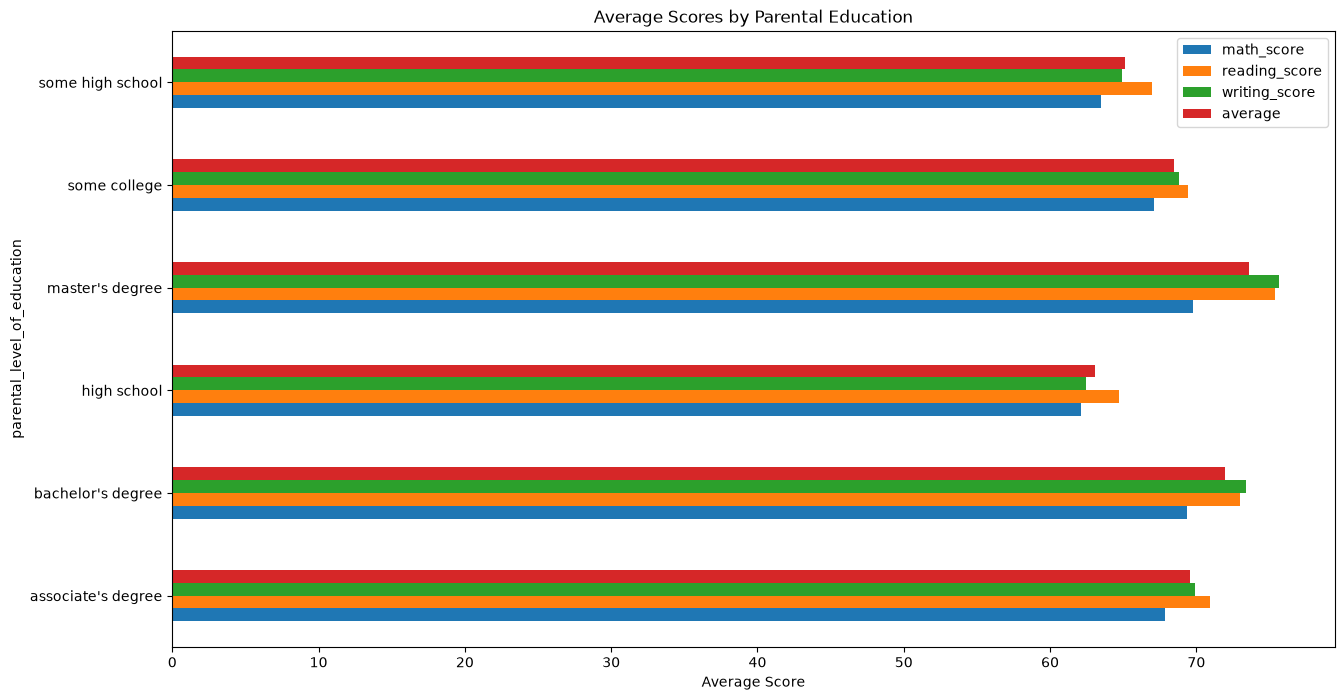

In [86]:
parent_group = (
    df.groupby('parental_level_of_education')[
        ['math_score', 'reading_score', 'writing_score', 'average']
    ].mean()
)

parent_group.plot(kind='barh', figsize=(15, 8))

plt.xlabel("Average Score")
plt.title("Average Scores by Parental Education")
plt.show()

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

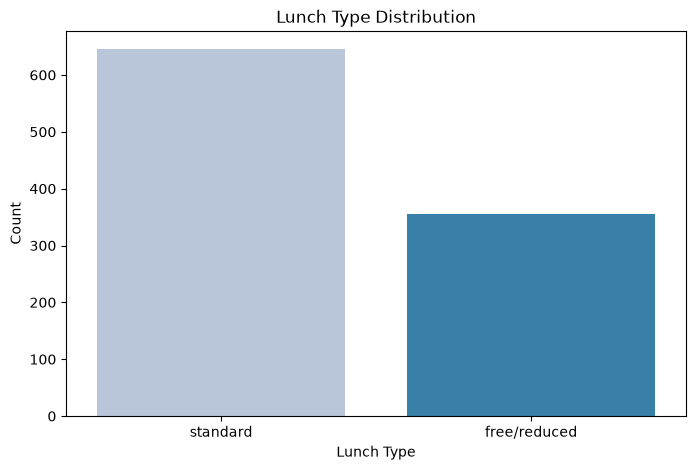

In [88]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='lunch', palette='PuBu')

plt.title("Lunch Type Distribution")
plt.xlabel("Lunch Type")
plt.ylabel("Count")

plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

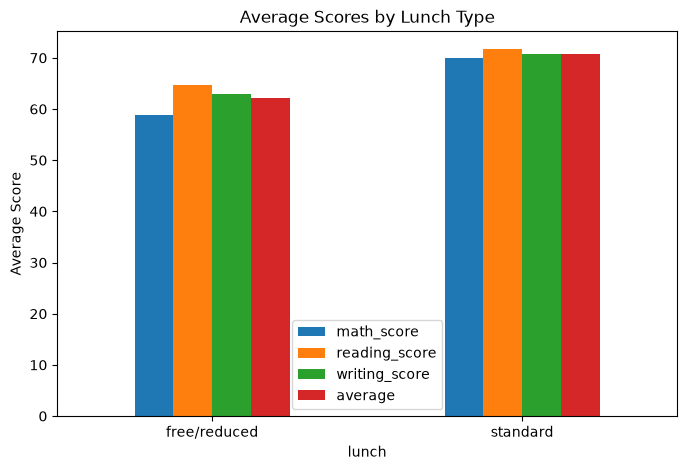

In [89]:
lunch_group = (
    df.groupby('lunch')[
        ['math_score', 'reading_score', 'writing_score', 'average']
    ].mean()
)

lunch_group.plot(kind='bar', figsize=(8, 5))

plt.ylabel("Average Score")
plt.title("Average Scores by Lunch Type")
plt.xticks(rotation=0)

plt.show()

#### Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 TEST PREPARATION COURSE COLUMN
- What is the distribution of the test preparation course?
- Does the test preparation course impact students' performance?

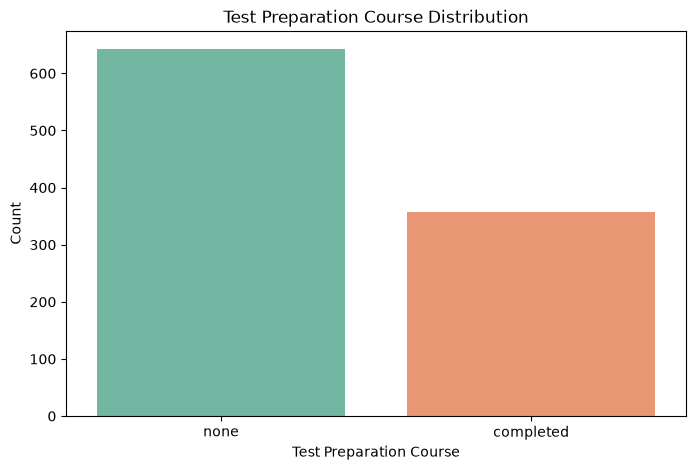

In [94]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='test_preparation_course', palette='Set2')

plt.title("Test Preparation Course Distribution")
plt.xlabel("Test Preparation Course")
plt.ylabel("Count")

plt.show()

#### Insights  
- Most studnets did not take Test Preparation Course

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

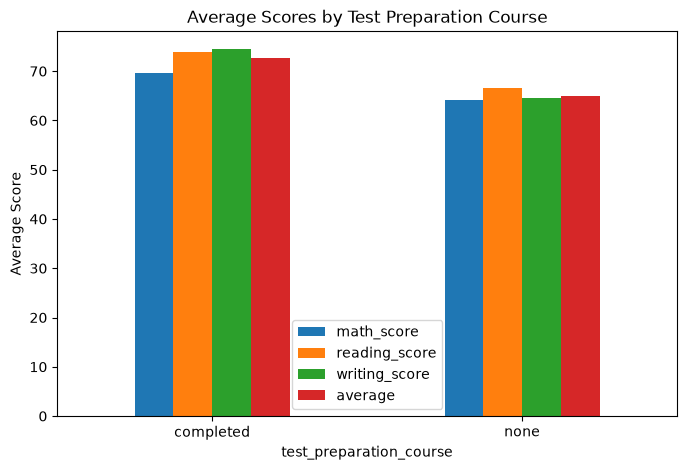

In [95]:
prep_group = (
    df.groupby('test_preparation_course')[
        ['math_score', 'reading_score', 'writing_score', 'average']
    ].mean()
)

prep_group.plot(kind='bar', figsize=(8,5))

plt.ylabel("Average Score")
plt.title("Average Scores by Test Preparation Course")
plt.xticks(rotation=0)

plt.show()

#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

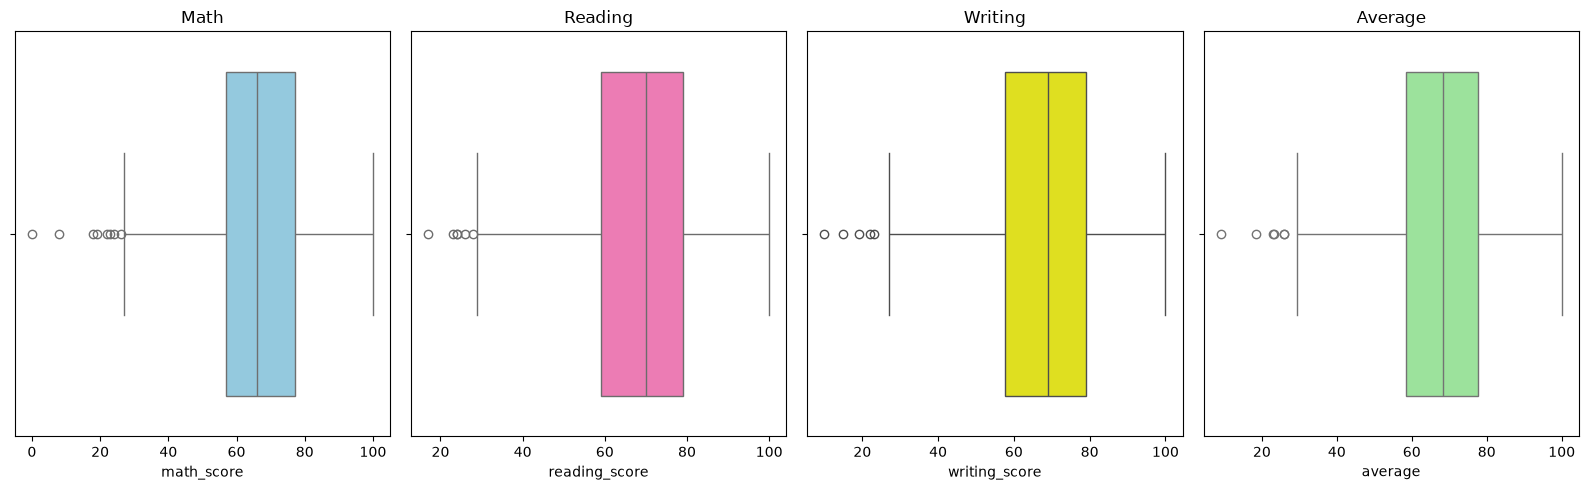

In [97]:
plt.figure(figsize=(16, 5))

# Math Score
plt.subplot(1, 4, 1)
sns.boxplot(x=df['math_score'], color='skyblue')
plt.title("Math")

# Reading Score
plt.subplot(1, 4, 2)
sns.boxplot(x=df['reading_score'], color='hotpink')
plt.title("Reading")

# Writing Score
plt.subplot(1, 4, 3)
sns.boxplot(x=df['writing_score'], color='yellow')
plt.title("Writing")

# Average Score
plt.subplot(1, 4, 4)
sns.boxplot(x=df['average'], color='lightgreen')
plt.title("Average")

plt.tight_layout()
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

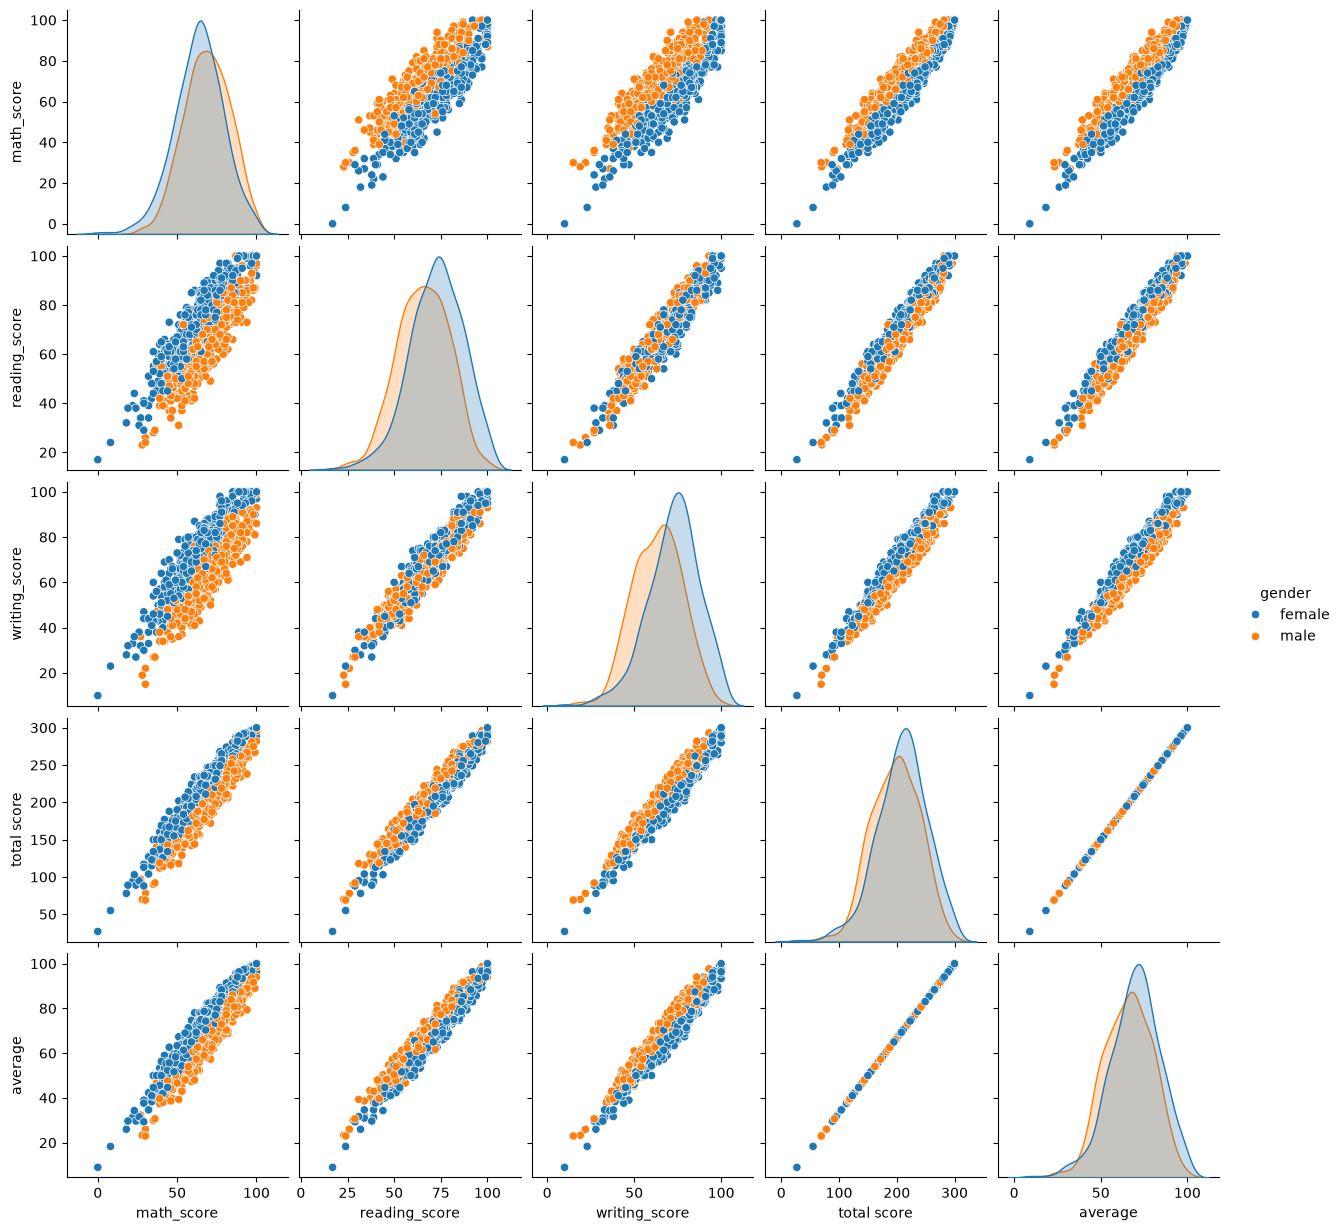

In [100]:
sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.